Импорт библиотек, загрузка данных, подготовка признаков и целевой переменной

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

train_path = r"C:\Users\Asus\Desktop\AI method\LB3\data\row\Data_Set_(A+B).csv"
test_path = r"C:\Users\Asus\Desktop\AI method\LB3\data\row\Data_Set_C.csv"

feature_cols = ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 
                'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3']

# Чтение с учётом русской локали Excel
# sep=';'  -> разделитель столбцов
# decimal=',' -> десятичный разделитель в числах
# encoding='cp1251' или 'utf-8-sig' -> кодировка кириллицы
try:
    df_train = pd.read_csv(train_path, sep=';', decimal=',', encoding='cp1251')
except Exception:
    # Фоллбэк на другие варианты, если первый не сработал
    try:
        df_train = pd.read_csv(train_path, sep=';', decimal=',', encoding='utf-8-sig')
    except Exception:
        df_train = pd.read_csv(train_path, sep=',', decimal='.', encoding='utf-8-sig')

print(f"Первые 3 строки:\n{df_train.head(3)}")
print(f"\nТипы данных:\n{df_train[feature_cols + ['Type']].dtypes}")

# Приведение к числовому типу (на случай, если decimal не сработал идеально)
for col in feature_cols + ['Type']:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce')

# Удаление бесконечностей и пропусков
df_train.replace([np.inf, -np.inf], np.nan, inplace=True)
rows_before = len(df_train)
df_train = df_train.dropna(subset=feature_cols + ['Type']).reset_index(drop=True)
rows_after = len(df_train)

if rows_after == 0:
    raise ValueError("Все строки удалены. Откройте CSV в Блокноте и проверьте разделители и десятичные знаки.")
    
print(f"[Очистка] Удалено {rows_before - rows_after} строк. Осталось: {rows_after}")

y = (df_train['Type'] == 4).astype(int).values
X = df_train[feature_cols].values

print(f"Размерность: {X.shape}")
print(f"Классы:\n{pd.Series(y).value_counts()}")

Первые 3 строки:
         I1        I2        I3        gx        gy        gz        ax  \
0  1.126697  0.021116  0.927601  0.712941 -0.252941  1.081765  0.043529   
1  1.039215  0.015083  0.953243  0.229412  0.276471  0.485294  0.013672   
2  0.911011  0.004525  0.947210  1.170588  0.222941  0.664118  0.011704   

         ay        az      V1real    V2real      V3real    N1  N2    N3  Type  
0  0.003174  0.011661 -249.352941  4.764706  265.235294 -5070  30  5239     1  
1 -0.005572  0.012164 -260.470588  0.000000  263.647059 -5320  -9  5391     1  
2  0.003720  0.005744 -268.411765  0.000000  268.411765 -4829   6  4786     1  

Типы данных:
I1        float64
I2        float64
I3        float64
gx        float64
gy        float64
gz        float64
ax        float64
ay        float64
az        float64
V1real    float64
V2real    float64
V3real    float64
N1          int64
N2          int64
N3          int64
Type        int64
dtype: object
[Очистка] Удалено 0 строк. Осталось: 176
Разме

Предварительный подбор гиперпараметров (Этап 1-2 методички)

In [2]:
# Быстрая проверка данных перед запуском
if np.isnan(X).any() or np.isinf(X).any():
    raise ValueError("В матрице признаков X найдены NaN или бесконечности. Проверьте очистку данных.")
if len(np.unique(y)) < 2:
    raise ValueError("Целевая переменная y содержит только один класс. Бинарная классификация невозможна.")

print("Запуск предварительной кросс-валидации (cv=3)...")
print("-" * 60)

best_cv_f1 = -1
best_params = None

for layers in [(30,), (64,), (100, 30)]:
    for act in ['relu', 'tanh']:
        for sol in ['adam', 'lbfgs']:
            for iters in [200, 500]:
                model = MLPClassifier(hidden_layer_sizes=layers, 
                                      activation=act, 
                                      solver=sol, 
                                      max_iter=iters, 
                                      random_state=42)
                try:
                    cv_f1 = cross_val_score(model, X, y, cv=3, scoring='f1').mean()
                    cv_acc = cross_val_score(model, X, y, cv=3, scoring='accuracy').mean()
                    print(f"Слои: {str(layers):15} | Актив: {act:6} | Solver: {sol:6} | Итер: {iters} | CV_F1: {cv_f1:.4f} | CV_Acc: {cv_acc:.4f}")
                    
                    if cv_f1 > best_cv_f1:
                        best_cv_f1 = cv_f1
                        best_params = {'hidden_layer_sizes': layers, 'activation': act, 'solver': sol, 'max_iter': iters}
                except Exception as e:
                    # Теперь ошибка будет видна в выводе
                    print(f"[SKIP] {layers}, {act}, {sol}, {iters} -> {e}")
                    continue

print("-" * 60)

if best_params is None:
    print("ВНИМАНИЕ: Все комбинации завершились с ошибкой. Применяется конфигурация по умолчанию.")
    best_params = {'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 500}
    best_cv_f1 = 0.0
    
print(f"Лучшие параметры по CV_F1: {best_params}")
print(f"Значение CV_F1: {best_cv_f1:.4f}")

BEST_PARAMS = best_params.copy()

Запуск предварительной кросс-валидации (cv=3)...
------------------------------------------------------------
Слои: (30,)           | Актив: relu   | Solver: adam   | Итер: 200 | CV_F1: 0.2647 | CV_Acc: 0.7784
Слои: (30,)           | Актив: relu   | Solver: adam   | Итер: 500 | CV_F1: 0.2647 | CV_Acc: 0.7784
Слои: (30,)           | Актив: relu   | Solver: lbfgs  | Итер: 200 | CV_F1: 0.1333 | CV_Acc: 0.8124
Слои: (30,)           | Актив: relu   | Solver: lbfgs  | Итер: 500 | CV_F1: 0.1333 | CV_Acc: 0.8124
Слои: (30,)           | Актив: tanh   | Solver: adam   | Итер: 200 | CV_F1: 0.0513 | CV_Acc: 0.8011
Слои: (30,)           | Актив: tanh   | Solver: adam   | Итер: 500 | CV_F1: 0.0513 | CV_Acc: 0.8011
Слои: (30,)           | Актив: tanh   | Solver: lbfgs  | Итер: 200 | CV_F1: 0.5332 | CV_Acc: 0.8637
Слои: (30,)           | Актив: tanh   | Solver: lbfgs  | Итер: 500 | CV_F1: 0.5134 | CV_Acc: 0.8580
Слои: (64,)           | Актив: relu   | Solver: adam   | Итер: 200 | CV_F1: 0.1846 | CV_Ac

Эксперимент на исходных данных (Этап 3-4 методички)

Исходные данные | Accuracy: 0.9545 | F1: 0.8947 | CV_F1: 0.7069
Параметры сети: {'hidden_layer_sizes': (100, 30), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 500}


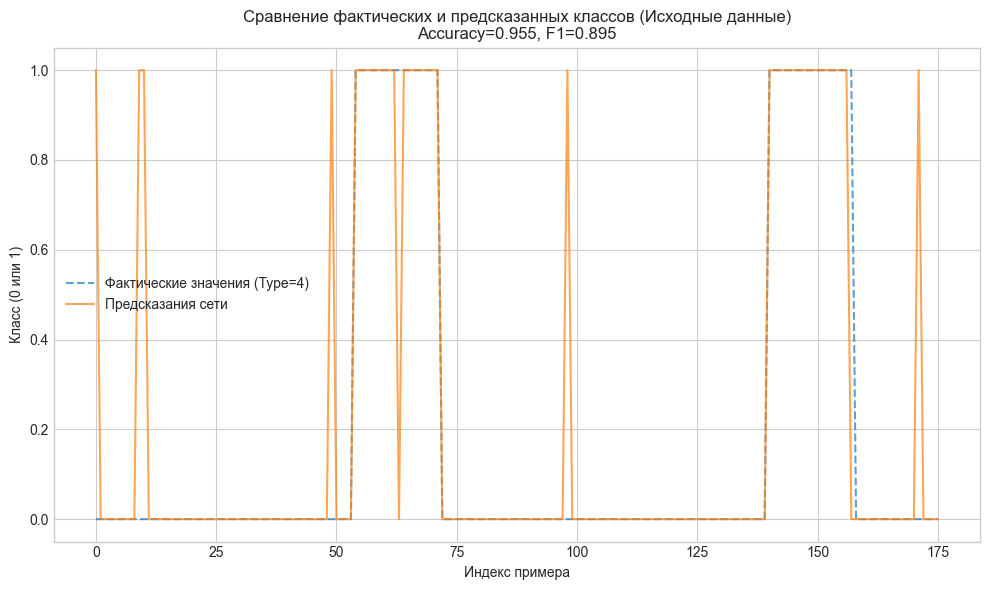

In [6]:
# Фиксируем параметры, найденные на этапе предварительного поиска
ANN_RAW = MLPClassifier(**BEST_PARAMS, random_state=42)

# Обучение и оценка
ANN_RAW.fit(X, y)
y_pred_raw = ANN_RAW.predict(X)

acc_raw = accuracy_score(y, y_pred_raw)
f1_raw = f1_score(y, y_pred_raw)
cv_raw = cross_val_score(ANN_RAW, X, y, cv=3, scoring='f1').mean()

print(f"Исходные данные | Accuracy: {acc_raw:.4f} | F1: {f1_raw:.4f} | CV_F1: {cv_raw:.4f}")
print(f"Параметры сети: {BEST_PARAMS}")

# График сравнения фактических и предсказанных значений
plt.figure()
plt.plot(y, label='Фактические значения (Type=4)', linestyle='--', alpha=0.7)
plt.plot(y_pred_raw, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс (0 или 1)')
plt.title(f'Сравнение фактических и предсказанных классов (Исходные данные)\nAccuracy={acc_raw:.3f}, F1={f1_raw:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('reports/plot_raw.png', dpi=150, bbox_inches='tight')
plt.show()


Эксперимент на отсортированных данных (Этап 5-6 методички)

Отсортированные данные | Accuracy: 0.9602 | F1: 0.9014 | CV_F1: 0.7706


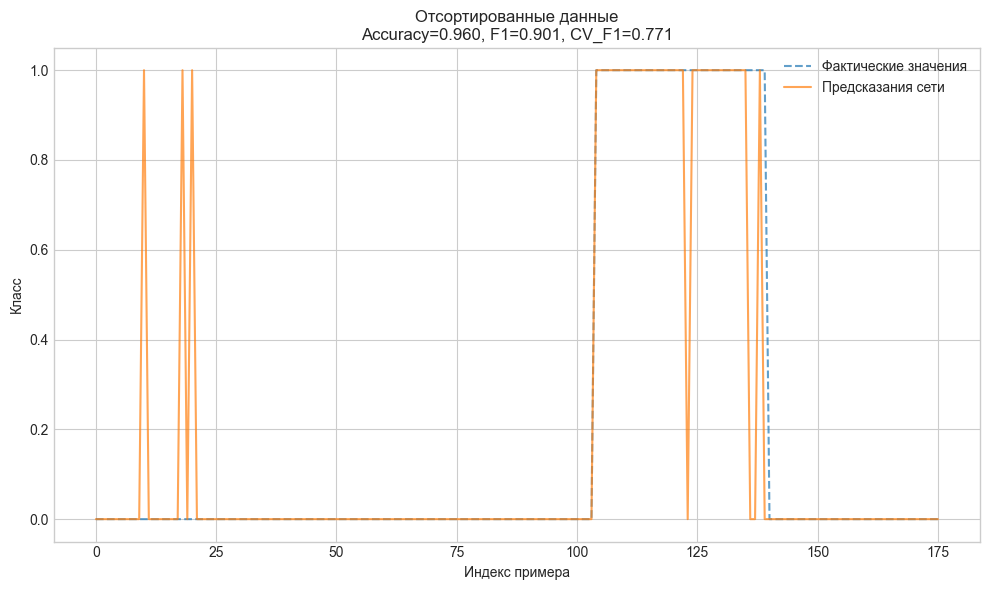

In [7]:
# Программная сортировка по целевому признаку (эмулирует Data Set_Train(Sort).xlsx)
df_sorted = df_train.copy().sort_values(by='Type').reset_index(drop=True)
X_sorted = df_sorted[feature_cols].values
y_sorted = (df_sorted['Type'] == 4).astype(int).values

ANN_SORT = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_SORT.fit(X_sorted, y_sorted)
y_pred_sorted = ANN_SORT.predict(X_sorted)

acc_sort = accuracy_score(y_sorted, y_pred_sorted)
f1_sort = f1_score(y_sorted, y_pred_sorted)
cv_sort = cross_val_score(ANN_SORT, X_sorted, y_sorted, cv=3, scoring='f1').mean()

print(f"Отсортированные данные | Accuracy: {acc_sort:.4f} | F1: {f1_sort:.4f} | CV_F1: {cv_sort:.4f}")

plt.figure()
plt.plot(y_sorted, label='Фактические значения', linestyle='--', alpha=0.7)
plt.plot(y_pred_sorted, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Отсортированные данные\nAccuracy={acc_sort:.3f}, F1={f1_sort:.3f}, CV_F1={cv_sort:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('reports/plot_sorted.png', dpi=150, bbox_inches='tight')
plt.show()

Эксперимент на нормализованных данных (Этап 7-9 методички)

Нормализованные данные | Accuracy: 1.0000 | F1: 1.0000 | CV_F1: 0.8864


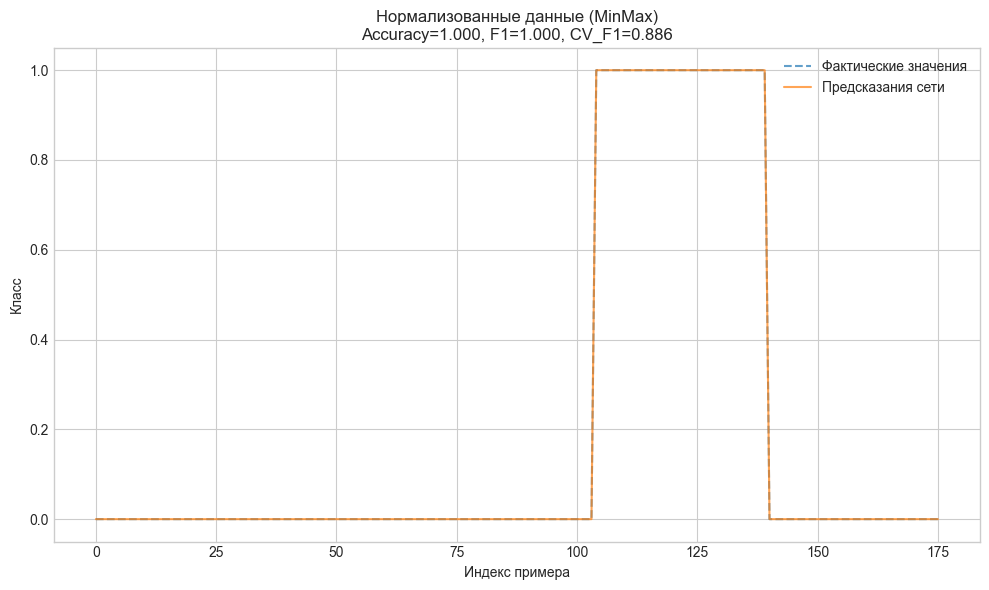

In [13]:
# Выбираем лучшую выборку из предыдущих двух шагов. 
# Для примера используем отсортированную, если её F1 был выше. 
# В реальном отчете замените условие на лучшую метрику.
use_sorted = f1_sort >= f1_raw
X_norm_base = X_sorted if use_sorted else X
y_norm_base = y_sorted if use_sorted else y

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_norm_base)

ANN_NORM = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_NORM.fit(X_norm, y_norm_base)
y_pred_norm = ANN_NORM.predict(X_norm)

acc_norm = accuracy_score(y_norm_base, y_pred_norm)
f1_norm = f1_score(y_norm_base, y_pred_norm)
cv_norm = cross_val_score(ANN_NORM, X_norm, y_norm_base, cv=3, scoring='f1').mean()

print(f"Нормализованные данные | Accuracy: {acc_norm:.4f} | F1: {f1_norm:.4f} | CV_F1: {cv_norm:.4f}")

plt.figure()
plt.plot(y_norm_base, label='Фактические значения', linestyle='--', alpha=0.7)
plt.plot(y_pred_norm, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Нормализованные данные (MinMax)\nAccuracy={acc_norm:.3f}, F1={f1_norm:.3f}, CV_F1={cv_norm:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('reports/plot_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


Эксперимент на сбалансированных данных (Этап 10-12 методички)

Применение SMOTE...
Применение ADASYN...
SMOTE  | Acc: 1.0000 | F1: 1.0000 | CV_F1: 0.9734
ADASYN | Acc: 1.0000 | F1: 1.0000 | CV_F1: 0.9553
Лучший метод балансировки: SMOTE


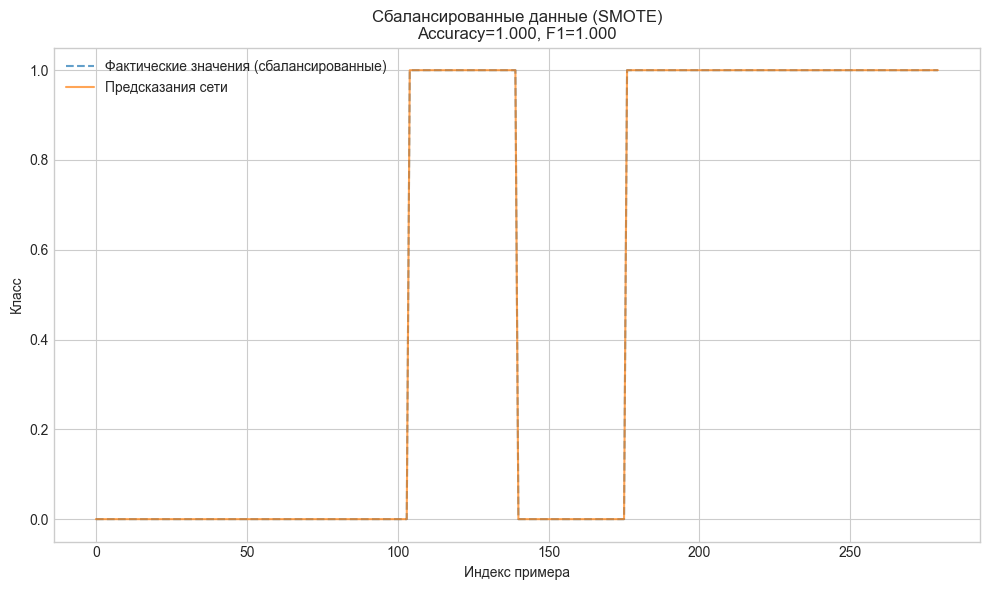

In [14]:
# Базовая выборка для балансировки - лучшая из предыдущих шагов. 
# Берем нормализованную, так как SMOTE/ADASYN работают лучше на масштабируемых данных.
X_bal_base = X_norm.copy()
y_bal_base = y_norm_base.copy()

print("Применение SMOTE...")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_bal_base, y_bal_base)

print("Применение ADASYN...")
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_bal_base, y_bal_base)

# Обучение на SMOTE
ANN_SMOTE = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_SMOTE.fit(X_smote, y_smote)
y_pred_smote = ANN_SMOTE.predict(X_smote)
f1_smote = f1_score(y_smote, y_pred_smote)
acc_smote = accuracy_score(y_smote, y_pred_smote)
cv_smote = cross_val_score(ANN_SMOTE, X_smote, y_smote, cv=3, scoring='f1').mean()
print(f"SMOTE  | Acc: {acc_smote:.4f} | F1: {f1_smote:.4f} | CV_F1: {cv_smote:.4f}")

# Обучение на ADASYN
ANN_ADASYN = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_ADASYN.fit(X_adasyn, y_adasyn)
y_pred_adasyn = ANN_ADASYN.predict(X_adasyn)
f1_adasyn = f1_score(y_adasyn, y_pred_adasyn)
acc_adasyn = accuracy_score(y_adasyn, y_pred_adasyn)
cv_adasyn = cross_val_score(ANN_ADASYN, X_adasyn, y_adasyn, cv=3, scoring='f1').mean()
print(f"ADASYN | Acc: {acc_adasyn:.4f} | F1: {f1_adasyn:.4f} | CV_F1: {cv_adasyn:.4f}")

# Выбираем лучший алгоритм балансировки
best_bal_method = 'SMOTE' if f1_smote >= f1_adasyn else 'ADASYN'
print(f"Лучший метод балансировки: {best_bal_method}")

X_best_bal = X_smote if best_bal_method == 'SMOTE' else X_adasyn
y_best_bal = y_smote if best_bal_method == 'SMOTE' else y_adasyn
y_pred_best_bal = y_pred_smote if best_bal_method == 'SMOTE' else y_pred_adasyn
f1_best_bal = f1_smote if best_bal_method == 'SMOTE' else f1_adasyn
acc_best_bal = acc_smote if best_bal_method == 'SMOTE' else acc_adasyn
cv_best_bal = cv_smote if best_bal_method == 'SMOTE' else cv_adasyn

plt.figure()
plt.plot(y_best_bal, label='Фактические значения (сбалансированные)', linestyle='--', alpha=0.7)
plt.plot(y_pred_best_bal, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Сбалансированные данные ({best_bal_method})\nAccuracy={acc_best_bal:.3f}, F1={f1_best_bal:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('reports/plot_balanced_SMOTE.png', dpi=300, bbox_inches='tight')
plt.show()


Проверка на контрольной выборке C (Этап 13 методички)

РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C
Accuracy: 0.9828
F1-Score: 0.9600
Параметры сети: {'hidden_layer_sizes': (100, 30), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 500}
Предобработка: Нормализация + SMOTE
                precision    recall  f1-score   support

Другой тип (0)       1.00      0.98      0.99        46
     Тип 4 (1)       0.92      1.00      0.96        12

      accuracy                           0.98        58
     macro avg       0.96      0.99      0.97        58
  weighted avg       0.98      0.98      0.98        58



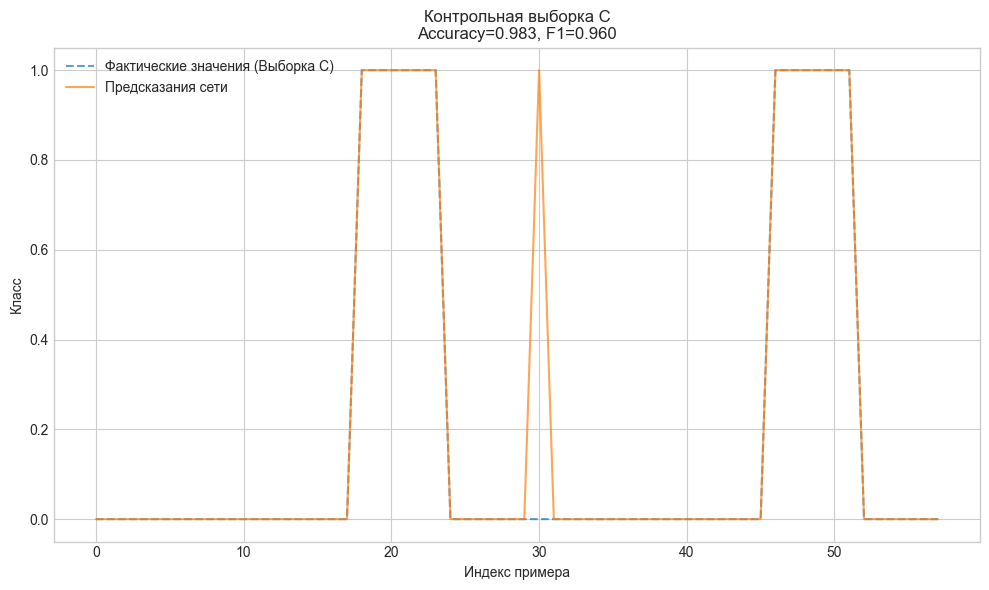

In [15]:
# Загрузка выборки C с теми же параметрами, что и обучающая
try:
    df_test = pd.read_csv(test_path, sep=';', decimal=',', encoding='cp1251')
except Exception:
    df_test = pd.read_csv(test_path, sep=';', decimal=',', encoding='utf-8-sig')

# Приведение признаков к числовому типу
for col in feature_cols:
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

# Очистка от бесконечностей и пропусков
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test = df_test.dropna(subset=feature_cols + ['Type']).reset_index(drop=True)

y_test = (df_test['Type'] == 4).astype(int).values
X_test = df_test[feature_cols].values

# Применяем ту же предобработку, что и при обучении лучшей модели
X_test_norm = scaler.transform(X_test)

# Выбираем финальную модель для проверки
final_model = ANN_SMOTE
# Если в вашем эксперименте лучше оказалась ADASYN или несбалансированная версия,
# замените переменную final_model на соответствующую обученную модель.

# Предсказание БЕЗ обучения (fit) на выборке C
y_pred_test = final_model.predict(X_test_norm)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print("=" * 60)
print("РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C")
print(f"Accuracy: {acc_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"Параметры сети: {BEST_PARAMS}")
print(f"Предобработка: Нормализация + {best_bal_method}")
print("=" * 60)

print(classification_report(y_test, y_pred_test, target_names=['Другой тип (0)', 'Тип 4 (1)']))

plt.figure()
plt.plot(y_test, label='Фактические значения (Выборка C)', linestyle='--', alpha=0.7)
plt.plot(y_pred_test, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Контрольная выборка C\nAccuracy={acc_test:.3f}, F1={f1_test:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('reports/plot_test_C.png', dpi=300, bbox_inches='tight')
plt.show()